# Análise de Churn de Clientes

**Objetivo de negócio:** entender *quanto* e *onde* a empresa está perdendo clientes (churn) para priorizar ações de retenção com o maior retorno possível.

A base é uma amostra fictícia de **150 clientes** de um produto SaaS, com plano contratado, receita recorrente mensal (MRR) e um indicador de churn (`1` = cancelou, `0` = ativo).

> **Como ler este notebook:** cada seção traz o número e, logo abaixo, o que ele significa para o negócio. A conclusão está no final, em *Insights e recomendações*.

## 1. Ingestão e qualidade dos dados

Reaproveito a função `carregar_dados` do módulo `ingestao.py` — a mesma que roda no pipeline — em vez de reescrever a leitura aqui. Isso mantém uma única fonte de verdade para a limpeza dos dados.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from ingestao import carregar_dados
from analise_churn import alertas_amostra, calcular_churn_plano

clientes = carregar_dados()
clientes.head()

,cliente_id,nome,data_cadastro,plano,mrr,churn
0,1,Ursula Melo 001,NaT,Basic,55.98,0
1,2,Xavier Guedes 002,2026-01-21,Basic,50.49,0
2,3,Queila Barros 003,NaT,Pro,254.20,0
3,4,Olivia Cardoso 004,2026-04-21,Enterprise,1257.81,0
4,5,Nathan Oliveira 005,2024-11-27,Basic,87.17,0


In [2]:
total = len(clientes)
datas_invalidas = int(clientes['data_cadastro'].isna().sum())
print(f'Total de clientes: {total}')
print(f'Datas de cadastro inválidas/ausentes: {datas_invalidas} '
      f'({datas_invalidas / total:.1%})')

Total de clientes: 150
Datas de cadastro inválidas/ausentes: 7 (4.7%)


**Leitura de negócio:** ~5% dos cadastros têm data inválida (ex.: `2024-02-30`, que não existe, ou o texto `data_invalida`). Não descartei essas linhas — o cliente e seu churn continuam válidos —, apenas marquei a data como nula. Fica registrado como um **problema de qualidade na origem** a ser tratado com o time que gera os dados.

## 2. Churn geral


In [3]:
taxa_geral = clientes['churn'].mean()
print(f'Taxa de churn geral: {taxa_geral:.1%} '
      f"({int(clientes['churn'].sum())} de {total} clientes)")

Taxa de churn geral: 18.7% (28 de 150 clientes)


## 3. Churn por plano

Agora o número que interessa: o churn é igual em todos os planos, ou existe um segmento mais frágil?

In [4]:
resultado = calcular_churn_plano(clientes)
resultado

,n_clientes,nao_nulos,total_churn,taxa_churn_percent
plano,,,,
Basic,76,76,12,15.789474
Enterprise,22,22,4,18.181818
Pro,52,52,12,23.076923


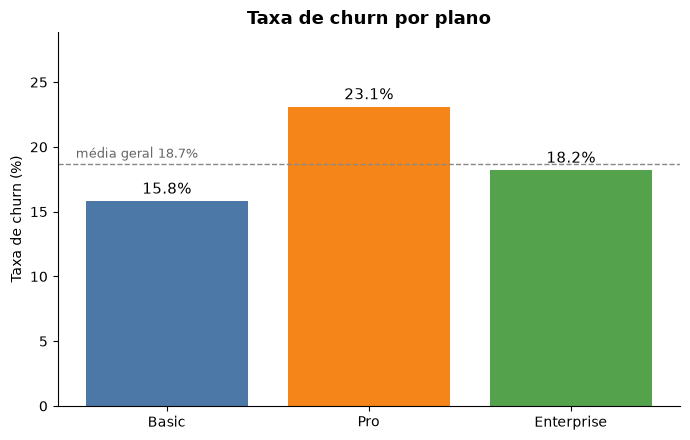

In [5]:
ordem = ['Basic', 'Pro', 'Enterprise']
dados = resultado.reindex(ordem)

fig, ax = plt.subplots(figsize=(7, 4.5))
cores = ['#4C78A8', '#F58518', '#54A24B']
barras = ax.bar(dados.index, dados['taxa_churn_percent'], color=cores)
ax.bar_label(barras, fmt='%.1f%%', padding=3, fontsize=11)
ax.axhline(taxa_geral * 100, color='#888', linestyle='--', linewidth=1)
ax.text(-0.45, taxa_geral * 100 + 0.5, f'média geral {taxa_geral:.1%}',
        color='#666', ha='left', fontsize=9)
ax.set_title('Taxa de churn por plano', fontsize=13, fontweight='bold')
ax.set_ylabel('Taxa de churn (%)')
ax.set_ylim(0, max(dados['taxa_churn_percent']) * 1.25)
for lado in ['top', 'right']:
    ax.spines[lado].set_visible(False)
fig.tight_layout()
fig.savefig('reports/figuras/churn_por_plano.png', dpi=120,
            bbox_inches='tight')
plt.show()

**Leitura de negócio:** o plano **Pro tem a maior taxa de churn (23,1%)**, bem acima da média. Em volume, é o plano que mais perde clientes proporcionalmente. Mas taxa não conta a história toda — falta o dinheiro.

## 4. O que a taxa esconde: receita em risco (MRR)

Um cliente Enterprise vale muito mais por mês que um Basic. Então perder 4 clientes Enterprise pode doer mais que perder 12 Basic. Vamos ver o **MRR perdido** (soma da receita mensal dos clientes que deram churn).

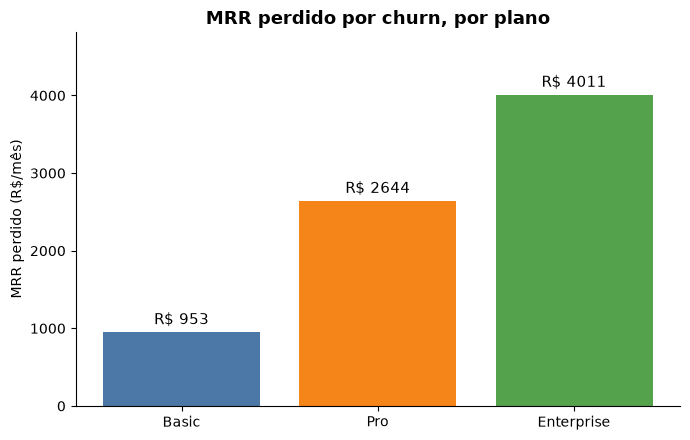

MRR total perdido por mês: R$ 7,608.38


In [6]:
mrr_risco = (clientes[clientes['churn'] == 1]
             .groupby('plano')['mrr'].sum()
             .reindex(ordem))

fig, ax = plt.subplots(figsize=(7, 4.5))
barras = ax.bar(mrr_risco.index, mrr_risco.values, color=cores)
ax.bar_label(barras, fmt='R$ %.0f', padding=3, fontsize=11)
ax.set_title('MRR perdido por churn, por plano',
             fontsize=13, fontweight='bold')
ax.set_ylabel('MRR perdido (R$/mês)')
ax.set_ylim(0, mrr_risco.max() * 1.20)
for lado in ['top', 'right']:
    ax.spines[lado].set_visible(False)
fig.tight_layout()
fig.savefig('reports/figuras/mrr_em_risco.png', dpi=120,
            bbox_inches='tight')
plt.show()

print(f'MRR total perdido por mês: R$ {mrr_risco.sum():,.2f}')

**A virada da análise:** o **Enterprise é o menor plano em número de clientes, mas o maior em receita perdida** (~R$ 4 mil/mês). O ranking por taxa (Pro na frente) e o ranking por dinheiro (Enterprise na frente) são **diferentes** — e é o dinheiro que paga a conta.

## 5. Cuidado estatístico: amostra pequena

Antes de sair agindo sobre o Enterprise, um alerta honesto de qualidade de análise: esse segmento tem poucos clientes. A função `alertas_amostra` sinaliza automaticamente qualquer plano com n < 30.

In [7]:
for alerta in alertas_amostra(resultado):
    print(alerta)

ATENÇÃO: o plano Enterprise tem apenas 22 clientes (amostra < 30). Sua taxa de churn de 18.2% é volátil — cada cliente pesa muito no percentual. Trate como indício, não como base para decisão isolada, e colete mais dados antes de agir.


## 6. Insights e recomendações

**Insights**

1. **Churn geral de 18,7%** — quase 1 em cada 5 clientes cancela. Patamar alto para SaaS, merece atenção.
2. **O plano Pro tem a maior taxa de churn (23,1%)** — é o problema de retenção em *volume*.
3. **O plano Enterprise concentra a maior perda de receita** (~R$ 4 mil/mês, ~53% do MRR perdido) mesmo com poucos cancelamentos — é o problema de retenção em *valor*.
4. **Taxa ≠ impacto financeiro:** priorizar só pela taxa de churn levaria a empresa a focar no Pro e ignorar onde mais se perde dinheiro.

**Recomendações**

- **Curto prazo (valor):** montar um acompanhamento próximo (customer success dedicado) para a carteira Enterprise — cada cliente salvo aqui vale ~15x um Basic em receita.
- **Curto prazo (volume):** investigar *por que* o Pro cancela mais (onboarding? preço? uso do produto?) com uma pesquisa ou análise de uso.
- **Antes de decidir sobre Enterprise:** coletar mais dados. Com n = 22, a taxa é volátil; tratar como indício forte, não como veredito.
- **Dados:** corrigir na origem os ~5% de datas inválidas para viabilizar análises de tempo de vida do cliente (ex.: churn por safra de cadastro).

**Próximos passos técnicos**

- Enriquecer a base com data de cancelamento e tempo de contrato.
- Análise de churn por *coorte* (mês de cadastro).
- Modelo preditivo de churn (ex.: regressão logística) para agir *antes* do cancelamento.